# Neural Network From Scratch (MNIST)

- Building NN from scratch without using Tensorflow/PyTorch on MNIST.
- Credit: Built while following Samson Zhang's 'Building a neural network FROM SCRATCH (no Tensorflow/Pytorch, just numpy & math)'

## Imports & Data Loading

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.get('data'), mnist.get('target')

In [2]:
import numpy as np # linear algebra
import pandas as pd # reading data
import matplotlib.pyplot as plt # visualization

## Data Exploration

In [3]:
data = pd.DataFrame(X, columns=mnist.feature_names)
data['label'] = y

In [4]:
data.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [5]:
data = np.array(data) # because we want to work in numpy awith the arrays
m, n = data.shape # data dimensions
np.random.shuffle(data) # shuffles data for further train-test split

In [6]:
data.shape

(70000, 785)

## Data Preprocessing

In [7]:
data_test = data[0:20000].T
X_test = data_test[:-1]
Y_test = data_test[-1]

In [8]:
Y_test

array(['5', '5', '3', ..., '9', '8', '1'], dtype=object)

In [9]:
X_test.shape

(784, 20000)

In [10]:
data_train = data[20000:m].T
y_train = data_train[-1]
X_train = data_train[:-1]

In [11]:
y_train

array(['4', '7', '8', ..., '4', '2', '2'], dtype=object)

In [12]:
X_train.shape

(784, 50000)

## Model Definition

In [13]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z1):
    return np.maximum(Z1, 0)

def softmax(Z2):
    # Numerical stability: subtract the max value from Z2 before exponentiation
    exp_Z2 = np.exp(Z2 - np.max(Z2, axis=0, keepdims=True))
    A2 = exp_Z2 / np.sum(exp_Z2, axis=0, keepdims=True)
    return A2

def forward_propogation(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    # Y is expected to be a 1D array of integer labels
    num_classes = np.max(Y) + 1 # Assuming classes are 0 to max(Y)
    one_hot_Y = np.zeros((num_classes, Y.size)) # Shape (num_classes, num_samples)
    one_hot_Y[Y, np.arange(Y.size)] = 1
    return one_hot_Y

def deriv_ReLU(Z1):
    # This should return an array of the same shape as Z1, with 1 where Z1 > 0 and 0 otherwise
    return (Z1 > 0).astype(float) # Element-wise derivative

def backward_propogation(Z1, A1, Z2, A2, W1, W2, X, y):
    m = y.size
    Y_one_hot = one_hot(y) # Renamed to avoid clash with function argument Y

    dZ2 = A2 - Y_one_hot
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True) # Sum along columns to get (10, 1)

    # Correct calculation for dZ1
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1) # Element-wise multiplication with derivative

    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True) # Sum along columns to get (10, 1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2


In [14]:
def get_predictions(A2):
    return np.argmax(A2, axis=0)

def get_accuracy(predictions, Y):
    # Y is the true labels (1D array of integers)
    # predictions is the predicted labels (1D array of integers)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_propogation(W1, b1, W2, b2, X)
        predictions = get_predictions(A2) # Get predictions from softmax output A2
        dW1, db1, dW2, db2 = backward_propogation(Z1, A1, Z2, A2, W1, W2, X, y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 100 == 0:
            print(f"Iteration: {i}")
            accuracy = get_accuracy(predictions, y)
            print(f"Accuracy: {accuracy:.4f}")
    return W1, b1, W2, b2


## Training

In [15]:
X_train = X_train.astype(np.float32)
X_train = X_train / 255.0
y_train = y_train.astype(np.int64)

W1, b1, W2, b2 = gradient_descent(X_train, y_train, 0.10, 500)

Iteration: 0
Accuracy: 0.1064
Iteration: 100
Accuracy: 0.5924
Iteration: 200
Accuracy: 0.7431
Iteration: 300
Accuracy: 0.7966
Iteration: 400
Accuracy: 0.8219


In [21]:
def test_predictions(X, Y, W1, b1, W2, b2):
    _, _, _, A2 = forward_propogation(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    accuracy = get_accuracy(predictions, Y)
    print(f"Test Accuracy: {accuracy:.4f}")
    return predictions, accuracy

## Evaluation

In [22]:
X_test = X_test.astype(np.float32) / 255.0
Y_test = Y_test.astype(np.int64)

test_preds, test_acc = test_predictions(X_test, Y_test, W1, b1, W2, b2)

Test Accuracy: 0.8429


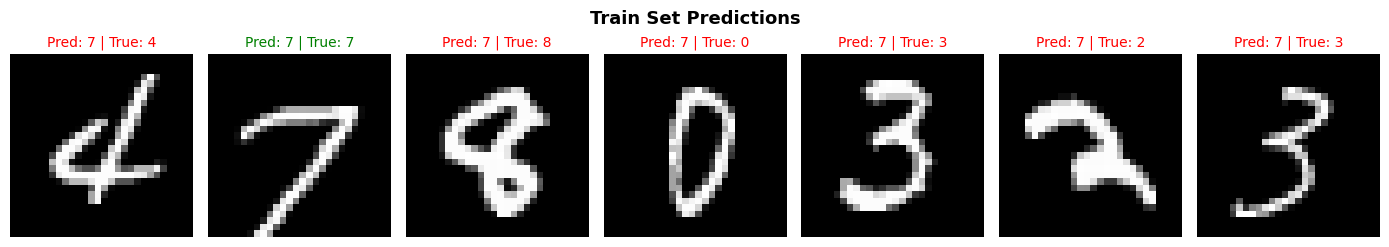

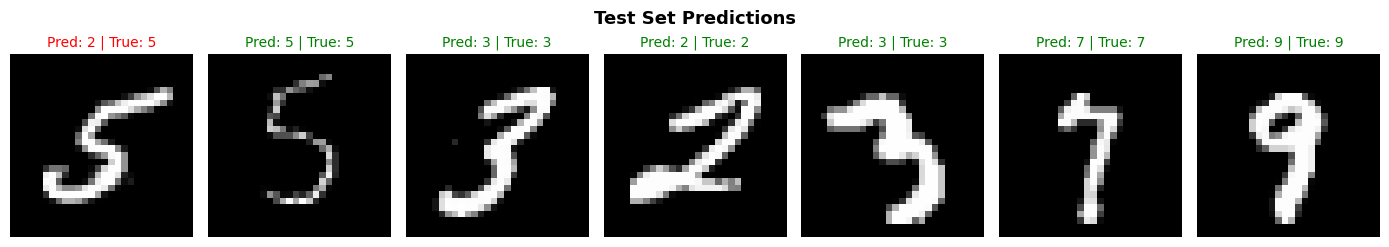

In [42]:
def show_predictions_grid(indices, X, Y, W1, b1, W2, b2, title="Predictions"):
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        current_image = X[:, idx, None]
        prediction = get_predictions(forward_propogation(W1, b1, W2, b2, current_image)[3])[0]
        label = Y[idx]

        image = current_image.reshape((28, 28))
        ax.imshow(image, cmap='gray', interpolation='nearest')

        correct = prediction == label
        color = 'green' if correct else 'red'
        ax.set_title(f"Pred: {prediction} | True: {label}", color=color, fontsize=10)
        ax.axis('off')

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

indices = list(range(7))
show_predictions_grid(indices, X_train, y_train, W1, b1, W2, b2, title="Train Set Predictions")
show_predictions_grid(indices, X_test, Y_test, W1, b1, W2, b2, title="Test Set Predictions")